# Airline Passenger Satisfaction — Multivariable Analysis

This notebook visualizes each predefined hypothesis while considering additional passenger or travel variables. It is strictly descriptive: **no hypothesis tests, p-values, confidence intervals, regression models, or statistical-significance conclusions are included**.

The visual analysis covers:

1. Service quality, satisfaction, and passenger/travel subgroups
2. Travel class, satisfaction, and potential contextual variables
3. Flight delays, satisfaction, and travel subgroups

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib.ticker import PercentFormatter

sns.set_theme(style="whitegrid", context="notebook")
COLORS = sns.color_palette("colorblind")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data/processed/airline_passenger_satisfaction_cleaned.csv"
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} passenger records and {df.shape[1]} columns.")

Loaded 129,880 passenger records and 70 columns.


## 1. Scope and conventions

- `is_satisfied = 1` represents **Satisfied**; `0` represents **Neutral or Dissatisfied**.
- Clean service fields exclude undocumented zero ratings.
- Every chart reports observed group rates and sample sizes where practical.
- Stratified patterns help reveal composition and possible confounding, but they are not adjusted estimates.
- Delay outliers remain in the data; intervals are used only to make patterns readable.
- Observed differences do not demonstrate statistical significance or causation.

In [2]:
class_order = ["Business", "Economy Plus", "Economy"]
travel_order = ["Business", "Personal"]
customer_order = ["Returning", "First-time"]
departure_order = ["No delay", "Short (1-15)", "Moderate (16-60)", "Long (>60)"]
arrival_order = departure_order + ["Missing"]

def grouped_satisfaction(*columns):
    return (
        df.groupby(list(columns), observed=True, dropna=False)
        .agg(Passengers=("passenger_id", "size"), Satisfied=("is_satisfied", "sum"), Satisfaction_rate=("is_satisfied", "mean"))
        .reset_index()
    )

def heatmap_rate(table, row, column, title, row_order=None, column_order=None, ax=None):
    matrix = table.pivot(index=row, columns=column, values="Satisfaction_rate")
    if row_order is not None:
        matrix = matrix.reindex(row_order)
    if column_order is not None:
        matrix = matrix.reindex(columns=column_order)
    sns.heatmap(matrix * 100, annot=True, fmt=".1f", cmap="YlGnBu", vmin=0, vmax=100,
                cbar_kws={"label": "Satisfaction rate (%)"}, ax=ax)
    ax.set(title=title, xlabel=column.replace("_", " ").title(), ylabel=row.replace("_", " ").title())
    return matrix

def format_rate_table(table):
    return table.style.hide(axis="index").format({
        "Passengers": "{:,}", "Satisfied": "{:,}", "Satisfaction_rate": "{:.1%}"
    })

## 2. Multivariable overview

The heatmap below summarizes linear correlations among selected numeric variables. Ratings are ordinal, and delays are strongly skewed, so this is a compact descriptive overview—not a test or a model.

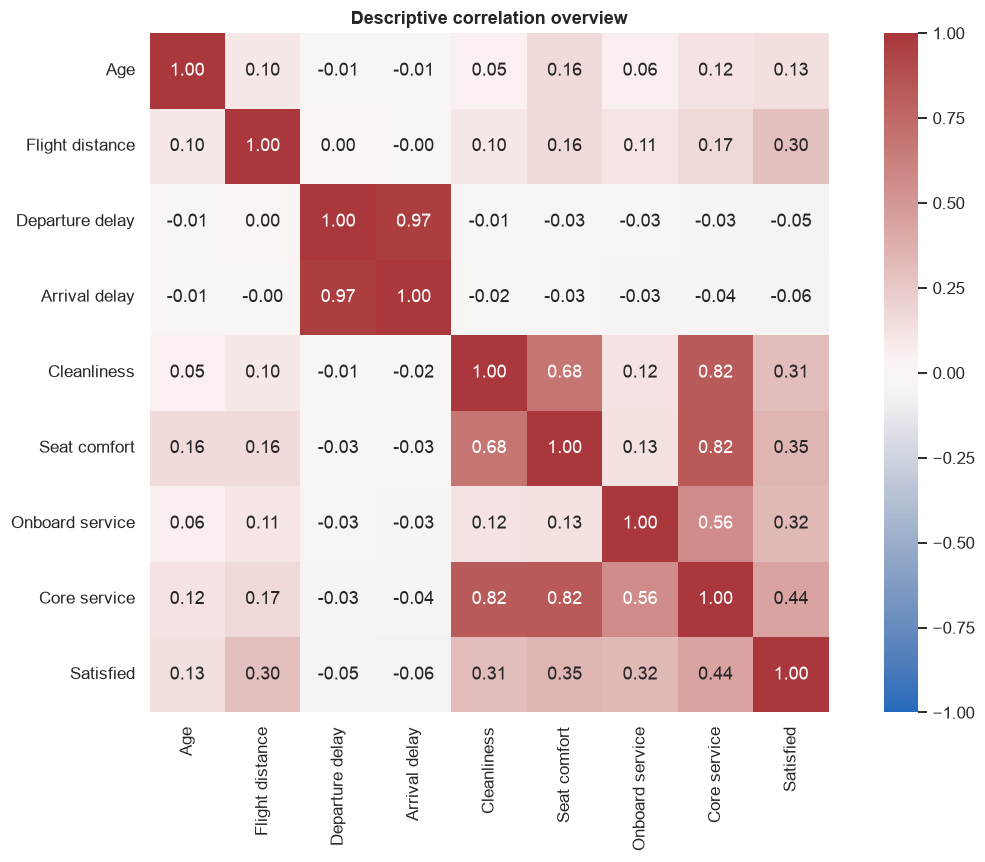

In [3]:
overview_columns = {
    "age": "Age",
    "flight_distance": "Flight distance",
    "departure_delay": "Departure delay",
    "arrival_delay": "Arrival delay",
    "cleanliness_rating_clean": "Cleanliness",
    "seat_comfort_rating_clean": "Seat comfort",
    "onboard_service_rating_clean": "Onboard service",
    "core_service_score_clean": "Core service",
    "is_satisfied": "Satisfied",
}
correlations = df[list(overview_columns)].rename(columns=overview_columns).corr()
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(correlations, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Descriptive correlation overview")
plt.tight_layout()
plt.show()

## 3. Hypothesis 1 variables: service quality, satisfaction, and subgroups

The first views show whether the observed service-rating pattern is similar across travel classes. This combines satisfaction, one service rating, and travel class.

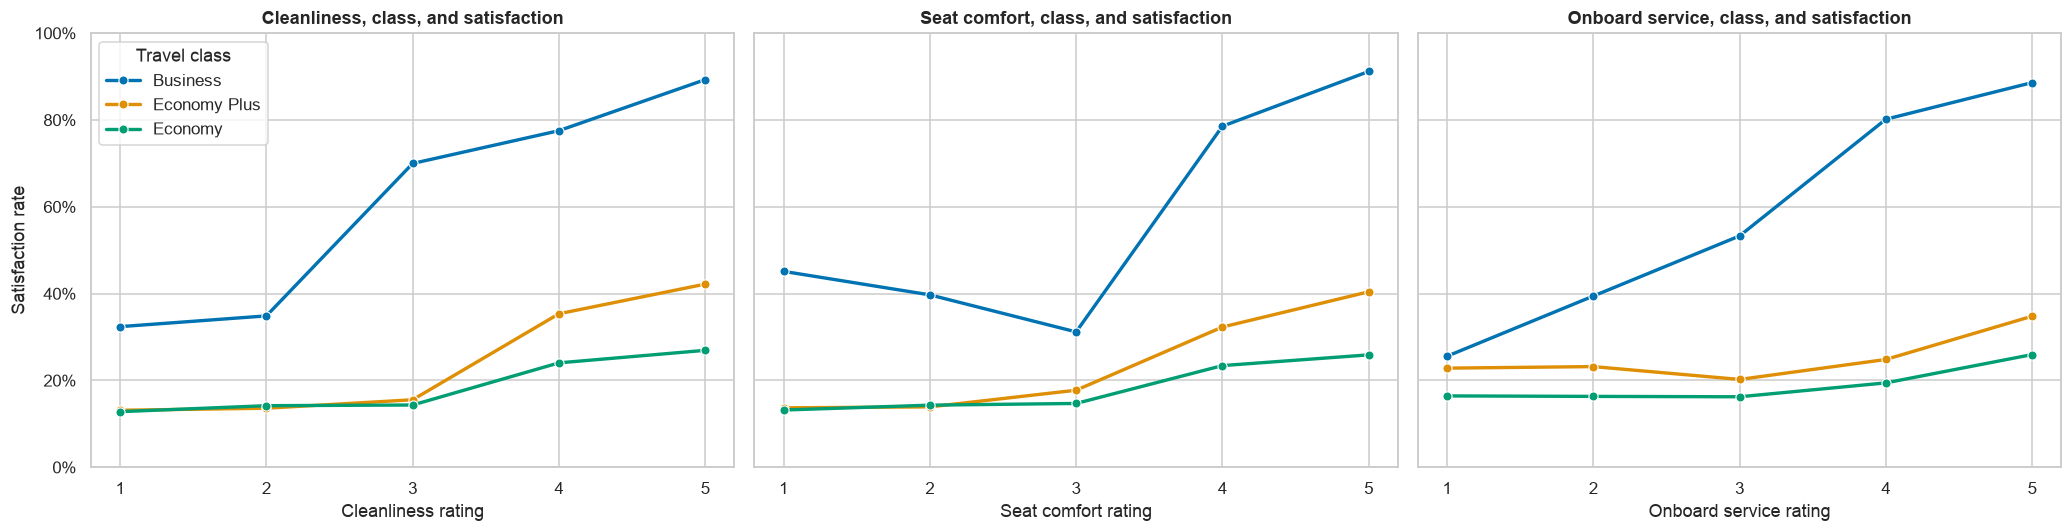

In [4]:
service_variables = {
    "cleanliness_rating_clean": "Cleanliness",
    "seat_comfort_rating_clean": "Seat comfort",
    "onboard_service_rating_clean": "Onboard service",
}

fig, axes = plt.subplots(1, 3, figsize=(19, 5), sharey=True)
service_class_tables = {}
for ax, (column, label) in zip(axes, service_variables.items()):
    table = grouped_satisfaction(column, "travel_class").dropna(subset=[column])
    table[column] = table[column].astype(int)
    service_class_tables[label] = table
    sns.lineplot(data=table, x=column, y="Satisfaction_rate", hue="travel_class", hue_order=class_order,
                 marker="o", linewidth=2.2, palette=COLORS[:3], ax=ax)
    ax.set(title=f"{label}, class, and satisfaction", xlabel=f"{label} rating", ylabel="Satisfaction rate", ylim=(0, 1))
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_xticks([1, 2, 3, 4, 5])
    if ax is not axes[0]:
        ax.get_legend().remove()
axes[0].legend(title="Travel class")
plt.tight_layout()
plt.show()

In [5]:
display(Markdown("**Group counts and observed rates underlying the service plots**"))
service_class_detail = pd.concat(
    [table.assign(Service=label).rename(columns={next(c for c in service_variables if service_variables[c] == label): "Rating"})
     for label, table in service_class_tables.items()],
    ignore_index=True,
)[["Service", "Rating", "travel_class", "Passengers", "Satisfied", "Satisfaction_rate"]]
display(format_rate_table(service_class_detail))

**Group counts and observed rates underlying the service plots**

Service,Rating,travel_class,Passengers,Satisfied,Satisfaction_rate
Cleanliness,1,Business,"5,863","1,899",32.4%
Cleanliness,1,Economy,"9,403","1,204",12.8%
Cleanliness,1,Economy Plus,"1,463",192,13.1%
Cleanliness,2,Business,"6,938","2,419",34.9%
Cleanliness,2,Economy,"11,351","1,610",14.2%
Cleanliness,2,Economy Plus,"1,824",248,13.6%
Cleanliness,3,Business,"15,909","11,132",70.0%
Cleanliness,3,Economy,"12,665","1,816",14.3%
Cleanliness,3,Economy Plus,"2,065",321,15.5%
Cleanliness,4,Business,"18,255","14,153",77.5%


### 3.1 Composite core-service score across class and customer type

The clean core score averages cleanliness, seat comfort, and onboard service. Analyst-defined score bands make subgroup rates readable without fitting a model.

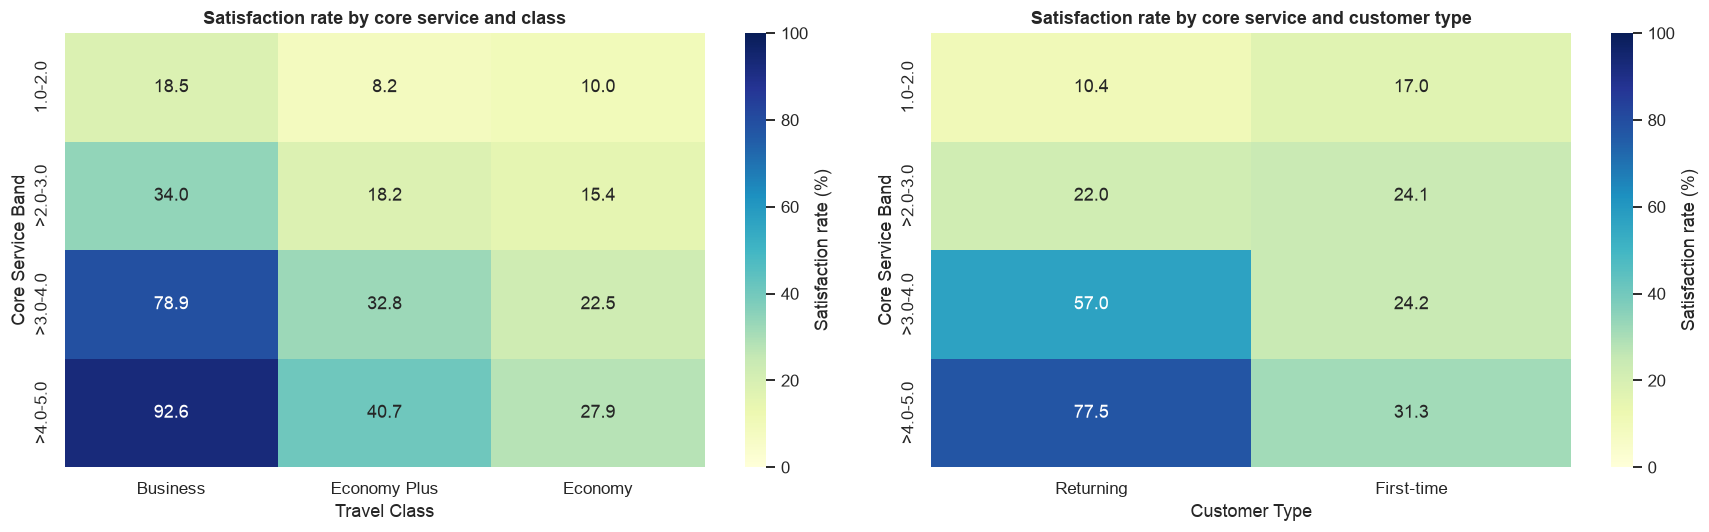

**Core-service band × travel class**

core_service_band,travel_class,Passengers,Satisfied,Satisfaction_rate
1.0-2.0,Business,"4,631",856,18.5%
1.0-2.0,Economy,"10,171","1,019",10.0%
1.0-2.0,Economy Plus,"1,692",139,8.2%
>2.0-3.0,Business,"13,385","4,550",34.0%
>2.0-3.0,Economy,"19,757","3,040",15.4%
>2.0-3.0,Economy Plus,"3,192",582,18.2%
>3.0-4.0,Business,"22,786","17,985",78.9%
>3.0-4.0,Economy,"19,242","4,330",22.5%
>3.0-4.0,Economy Plus,"3,103","1,018",32.8%
>4.0-5.0,Business,"21,358","19,775",92.6%


**Core-service band × customer type**

core_service_band,customer_type,Passengers,Satisfied,Satisfaction_rate
1.0-2.0,First-time,"4,565",774,17.0%
1.0-2.0,Returning,"11,929","1,240",10.4%
>2.0-3.0,First-time,"7,973","1,923",24.1%
>2.0-3.0,Returning,"28,361","6,249",22.0%
>3.0-4.0,First-time,"7,289","1,767",24.2%
>3.0-4.0,Returning,"37,842","21,566",57.0%
>4.0-5.0,First-time,"3,953","1,236",31.3%
>4.0-5.0,Returning,"27,968","21,673",77.5%


In [6]:
core_edges = [0.999, 2, 3, 4, 5.001]
core_labels = ["1.0-2.0", ">2.0-3.0", ">3.0-4.0", ">4.0-5.0"]
df["core_service_band"] = pd.cut(df["core_service_score_clean"], bins=core_edges, labels=core_labels, include_lowest=True)

core_class = grouped_satisfaction("core_service_band", "travel_class")
core_customer = grouped_satisfaction("core_service_band", "customer_type")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
heatmap_rate(core_class, "core_service_band", "travel_class", "Satisfaction rate by core service and class", core_labels, class_order, axes[0])
heatmap_rate(core_customer, "core_service_band", "customer_type", "Satisfaction rate by core service and customer type", core_labels, customer_order, axes[1])
plt.tight_layout()
plt.show()

display(Markdown("**Core-service band × travel class**"))
display(format_rate_table(core_class))
display(Markdown("**Core-service band × customer type**"))
display(format_rate_table(core_customer))

**Descriptive reading only:** If lines or heatmap gradients differ across subgroups, the service–satisfaction association may depend on sample composition. No interaction or significance test is performed here.

## 4. Hypothesis 2 variables: travel class, satisfaction, and context

Travel purpose and customer type may differ substantially across classes. These stratified plots show class satisfaction rates within each available context rather than pooling everyone together.

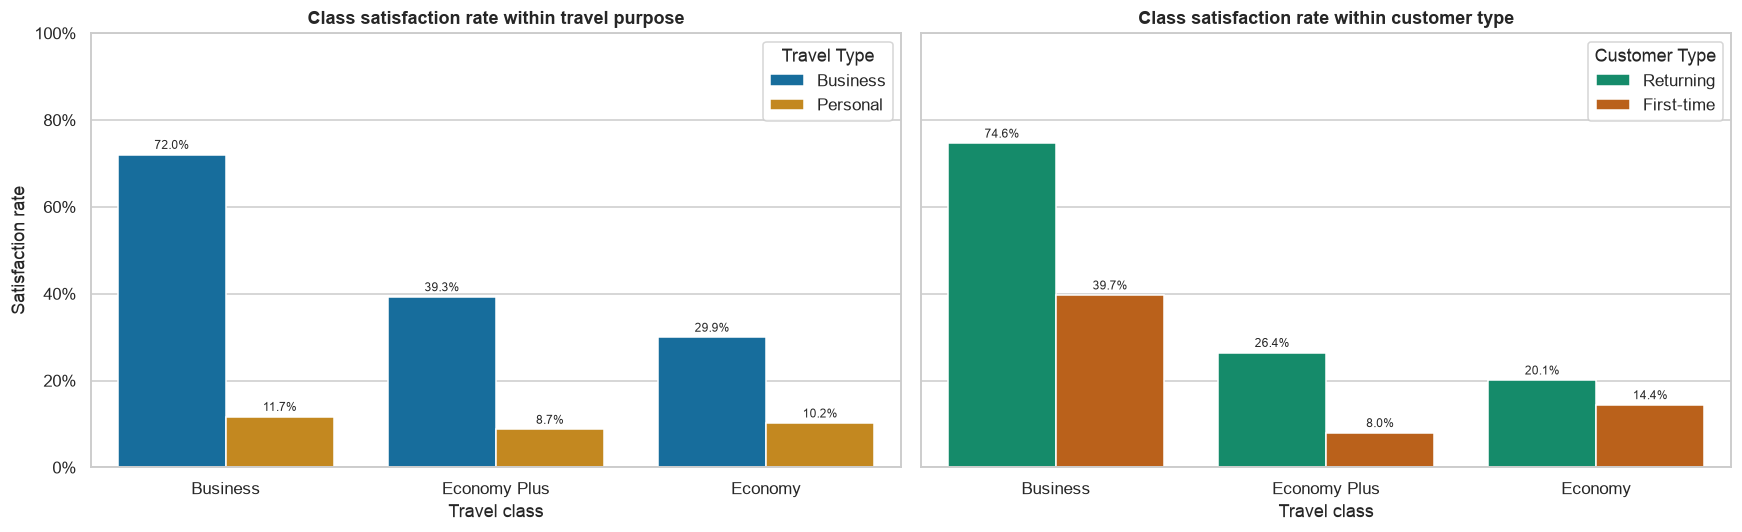

**Travel class × travel purpose**

travel_class,travel_type,Passengers,Satisfied,Satisfaction_rate
Business,Business,"59,487","42,853",72.0%
Business,Personal,"2,673",313,11.7%
Economy,Business,"25,304","7,578",29.9%
Economy,Personal,"33,005","3,365",10.2%
Economy Plus,Business,"4,902","1,925",39.3%
Economy Plus,Personal,"4,509",394,8.7%


**Travel class × customer type**

travel_class,customer_type,Passengers,Satisfied,Satisfaction_rate
Business,First-time,"9,231","3,662",39.7%
Business,Returning,"52,929","39,504",74.6%
Economy,First-time,"13,634","1,965",14.4%
Economy,Returning,"44,675","8,978",20.1%
Economy Plus,First-time,915,73,8.0%
Economy Plus,Returning,"8,496","2,246",26.4%


In [7]:
class_travel = grouped_satisfaction("travel_class", "travel_type")
class_customer = grouped_satisfaction("travel_class", "customer_type")

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
sns.barplot(data=class_travel, x="travel_class", y="Satisfaction_rate", hue="travel_type",
            order=class_order, hue_order=travel_order, palette=COLORS[:2], ax=axes[0])
axes[0].set(title="Class satisfaction rate within travel purpose", xlabel="Travel class", ylabel="Satisfaction rate", ylim=(0, 1))
sns.barplot(data=class_customer, x="travel_class", y="Satisfaction_rate", hue="customer_type",
            order=class_order, hue_order=customer_order, palette=COLORS[2:4], ax=axes[1])
axes[1].set(title="Class satisfaction rate within customer type", xlabel="Travel class", ylabel="Satisfaction rate", ylim=(0, 1))
for ax in axes:
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    for container in ax.containers:
        ax.bar_label(container, labels=[f"{bar.get_height():.1%}" for bar in container], padding=2, fontsize=8)
    ax.legend(title=ax.get_legend().get_title().get_text().replace("_", " ").title())
plt.tight_layout()
plt.show()

display(Markdown("**Travel class × travel purpose**"))
display(format_rate_table(class_travel))
display(Markdown("**Travel class × customer type**"))
display(format_rate_table(class_customer))

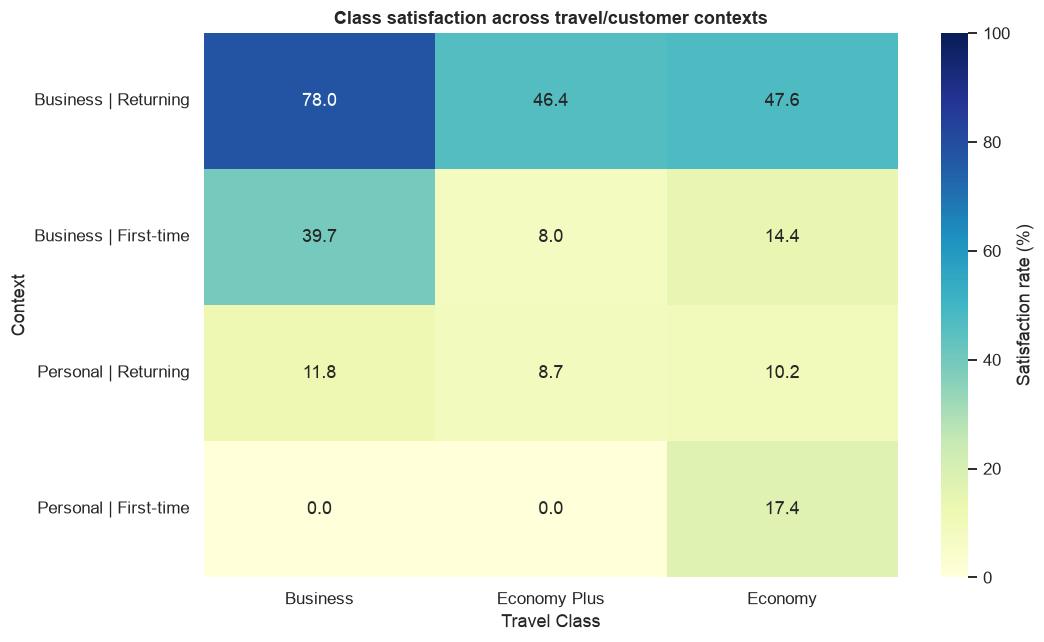

travel_class,travel_type,customer_type,Passengers,Satisfied,Satisfaction_rate
Business,Business,First-time,"9,218","3,662",39.7%
Business,Business,Returning,"50,269","39,191",78.0%
Business,Personal,First-time,13,0,0.0%
Business,Personal,Returning,"2,660",313,11.8%
Economy,Business,First-time,"13,450","1,933",14.4%
Economy,Business,Returning,"11,854","5,645",47.6%
Economy,Personal,First-time,184,32,17.4%
Economy,Personal,Returning,"32,821","3,333",10.2%
Economy Plus,Business,First-time,911,73,8.0%
Economy Plus,Business,Returning,"3,991","1,852",46.4%


In [8]:
class_context = grouped_satisfaction("travel_class", "travel_type", "customer_type")
class_context["Context"] = class_context["travel_type"] + " | " + class_context["customer_type"]
context_order = [f"{travel} | {customer}" for travel in travel_order for customer in customer_order]

fig, ax = plt.subplots(figsize=(10, 6))
heatmap_rate(class_context, "Context", "travel_class", "Class satisfaction across travel/customer contexts", context_order, class_order, ax)
plt.tight_layout()
plt.show()
display(format_rate_table(class_context[["travel_class", "travel_type", "customer_type", "Passengers", "Satisfied", "Satisfaction_rate"]]))

**Descriptive reading only:** These plots expose differences hidden by the overall class average. Very small cells should not be interpreted as stable estimates; no class comparison has been tested or adjusted.

## 5. Hypothesis 3 variables: flight delay, satisfaction, and subgroups

The delay views stratify satisfaction rates by travel class and travel purpose. Missing arrival delay remains a separate category.

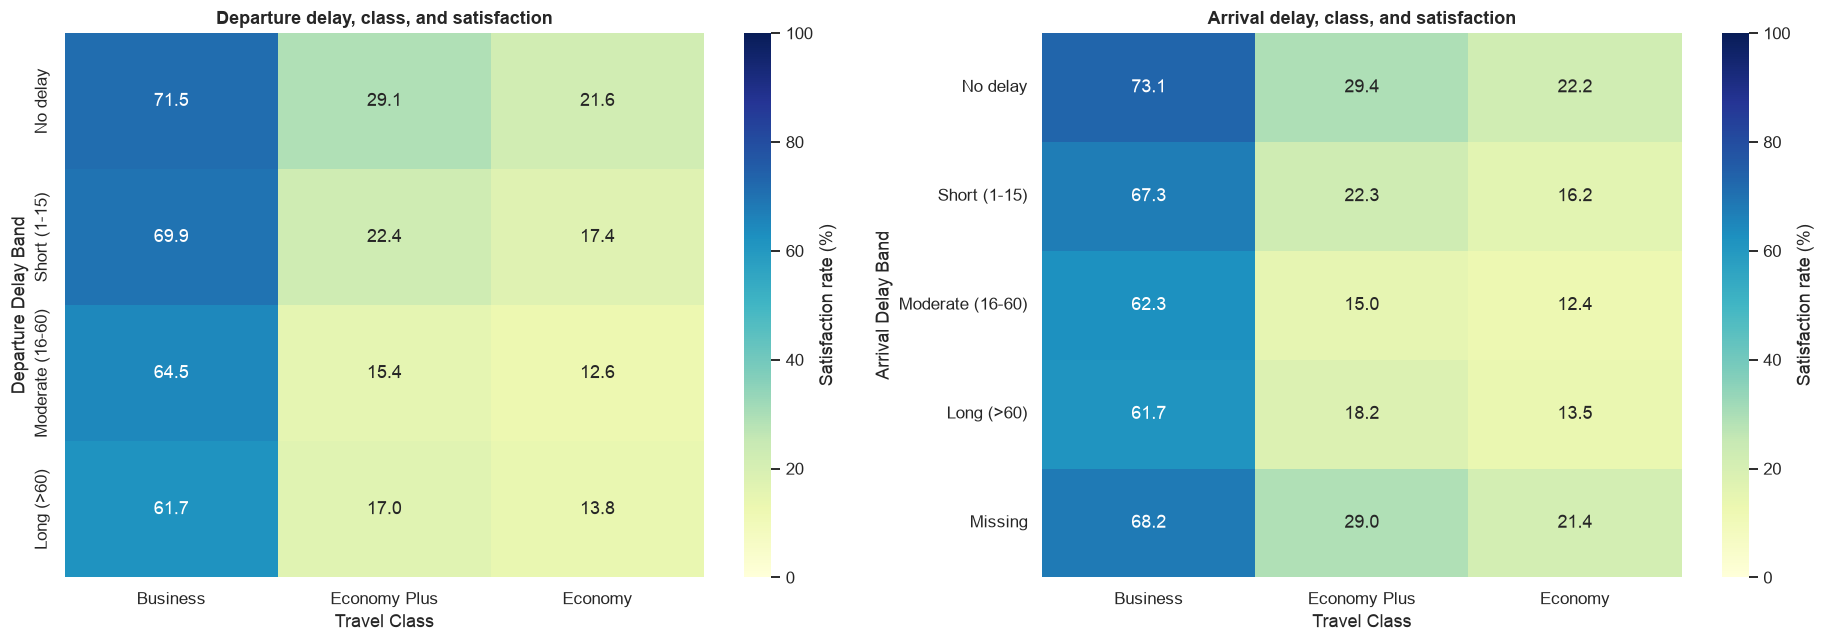

**Departure-delay band × travel class**

departure_delay_band,travel_class,Passengers,Satisfied,Satisfaction_rate
Long (>60),Business,"4,085","2,522",61.7%
Long (>60),Economy,"4,200",579,13.8%
Long (>60),Economy Plus,690,117,17.0%
Moderate (16-60),Business,"9,405","6,067",64.5%
Moderate (16-60),Economy,"8,879","1,116",12.6%
Moderate (16-60),Economy Plus,"1,478",228,15.4%
No delay,Business,"35,032","25,042",71.5%
No delay,Economy,"33,079","7,131",21.6%
No delay,Economy Plus,"5,245","1,526",29.1%
Short (1-15),Business,"13,638","9,535",69.9%


**Arrival-delay band × travel class**

arrival_delay_band,travel_class,Passengers,Satisfied,Satisfaction_rate
Long (>60),Business,"4,092","2,524",61.7%
Long (>60),Economy,"4,294",581,13.5%
Long (>60),Economy Plus,702,128,18.2%
Missing,Business,170,116,68.2%
Missing,Economy,192,41,21.4%
Missing,Economy Plus,31,9,29.0%
Moderate (16-60),Business,"9,548","5,945",62.3%
Moderate (16-60),Economy,"9,331","1,161",12.4%
Moderate (16-60),Economy Plus,"1,591",239,15.0%
No delay,Business,"35,296","25,792",73.1%


In [9]:
departure_class = grouped_satisfaction("departure_delay_band", "travel_class")
arrival_class = grouped_satisfaction("arrival_delay_band", "travel_class")

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
heatmap_rate(departure_class, "departure_delay_band", "travel_class", "Departure delay, class, and satisfaction", departure_order, class_order, axes[0])
heatmap_rate(arrival_class, "arrival_delay_band", "travel_class", "Arrival delay, class, and satisfaction", arrival_order, class_order, axes[1])
plt.tight_layout()
plt.show()

display(Markdown("**Departure-delay band × travel class**"))
display(format_rate_table(departure_class))
display(Markdown("**Arrival-delay band × travel class**"))
display(format_rate_table(arrival_class))

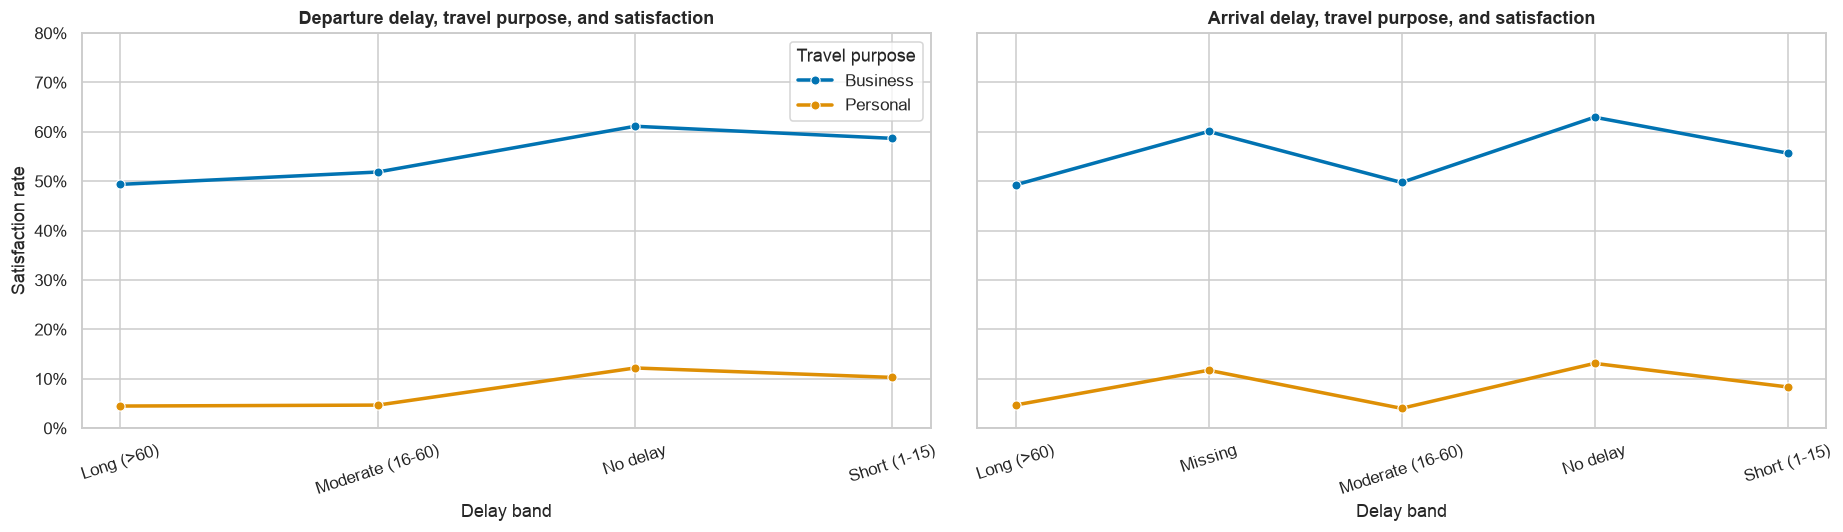

In [10]:
departure_travel = grouped_satisfaction("departure_delay_band", "travel_type")
arrival_travel = grouped_satisfaction("arrival_delay_band", "travel_type")

fig, axes = plt.subplots(1, 2, figsize=(17, 5), sharey=True)
for ax, table, category, order, title in [
    (axes[0], departure_travel, "departure_delay_band", departure_order, "Departure delay"),
    (axes[1], arrival_travel, "arrival_delay_band", arrival_order, "Arrival delay"),
]:
    sns.lineplot(data=table, x=category, y="Satisfaction_rate", hue="travel_type", hue_order=travel_order,
                 marker="o", linewidth=2.3, palette=COLORS[:2], sort=False, ax=ax)
    ax.set(title=f"{title}, travel purpose, and satisfaction", xlabel="Delay band", ylabel="Satisfaction rate", ylim=(0, .8))
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.tick_params(axis="x", rotation=18)
    if ax is not axes[0]:
        ax.get_legend().remove()
axes[0].legend(title="Travel purpose")
plt.tight_layout()
plt.show()

### 5.1 Finer delay intervals across travel class

The intervals preserve all nonmissing delays, including severe disruptions. They provide a more detailed descriptive shape than the four broad bands.

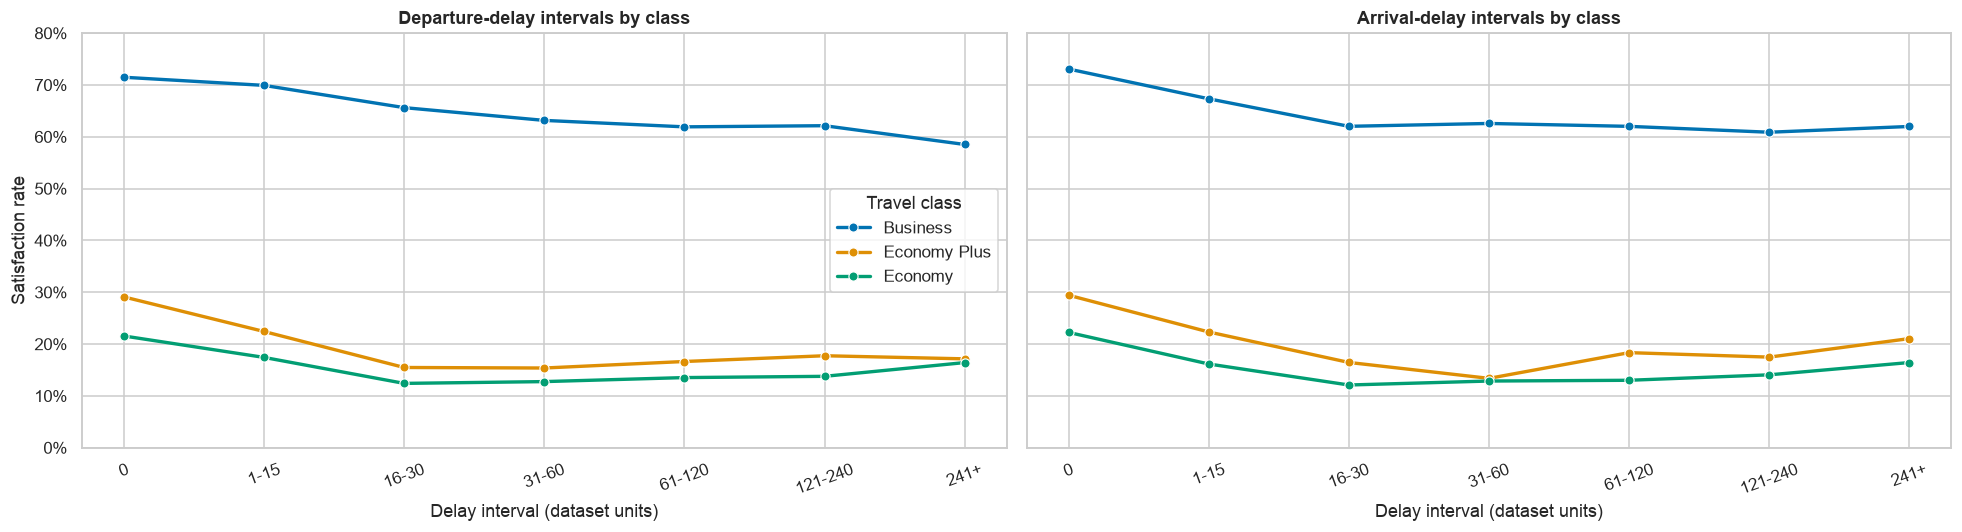

In [11]:
fine_edges = [-1, 0, 15, 30, 60, 120, 240, np.inf]
fine_labels = ["0", "1-15", "16-30", "31-60", "61-120", "121-240", "241+"]
df["departure_delay_interval"] = pd.cut(df["departure_delay"], bins=fine_edges, labels=fine_labels)
df["arrival_delay_interval"] = pd.cut(df["arrival_delay"], bins=fine_edges, labels=fine_labels)

fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)
for ax, interval, title in [
    (axes[0], "departure_delay_interval", "Departure-delay intervals by class"),
    (axes[1], "arrival_delay_interval", "Arrival-delay intervals by class"),
]:
    table = grouped_satisfaction(interval, "travel_class").dropna(subset=[interval])
    sns.lineplot(data=table, x=interval, y="Satisfaction_rate", hue="travel_class", hue_order=class_order,
                 marker="o", linewidth=2.2, palette=COLORS[:3], sort=False, ax=ax)
    ax.set(title=title, xlabel="Delay interval (dataset units)", ylabel="Satisfaction rate", ylim=(0, .8))
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.tick_params(axis="x", rotation=20)
    if ax is not axes[0]:
        ax.get_legend().remove()
axes[0].legend(title="Travel class")
plt.tight_layout()
plt.show()

**Descriptive reading only:** Stratified delay patterns can reveal whether the pooled relationship varies by travel context. No nonlinear model, interaction test, missing-value imputation, or outlier removal is performed.

## 6. Visual review checklist before testing

Before choosing formal methods, use the plots to assess:

- Whether service–satisfaction patterns have similar shapes across classes and customer types
- Whether the overall class pattern persists within travel-purpose and customer-type strata
- Whether delay patterns appear nonlinear or differ by class and travel purpose
- Whether subgroup cells are sufficiently large for reliable comparison
- Whether missing arrival delays need a separate sensitivity analysis
- Which variables may need to be included together in a future adjusted model

No hypothesis has been accepted, rejected, or formally tested in this notebook.